In [2]:
from google.colab import files

uploaded = files.upload()

Saving transformed_train.csv to transformed_train.csv


In [99]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('/content/transformed_train.csv')

dataset['timestamp'].unique()

array(['0:0', '0:15', '0:30', '0:45', '1:0', '1:15', '1:30', '1:45',
       '2:0', '2:15', '2:30', '2:45', '3:0', '3:15', '3:30', '3:45',
       '4:0', '4:15', '4:30', '4:45', '5:0', '5:15', '5:30', '5:45',
       '6:0', '6:15', '6:30', '6:45', '7:0', '7:15', '7:30', '7:45',
       '8:0', '8:15', '8:30', '8:45', '9:0', '9:15', '9:30', '9:45',
       '10:0', '10:15', '10:30', '10:45', '11:0', '11:15', '11:30',
       '11:45', '12:0', '12:15', '12:30', '12:45', '13:0', '13:15',
       '13:30', '13:45', '14:0', '14:15', '14:30', '14:45', '15:0',
       '15:15', '15:30', '15:45', '16:0', '16:15', '16:30', '16:45',
       '17:0', '17:15', '17:30', '17:45', '18:0', '18:15', '18:30',
       '18:45', '19:0', '19:15', '19:30', '19:45', '20:0', '20:15',
       '20:30', '20:45', '21:0', '21:15', '21:30', '21:45', '22:0',
       '22:15', '22:30', '22:45', '23:0', '23:15', '23:30', '23:45'],
      dtype=object)

# Changing timestamp to cyclic feature - using sine and cos

In [100]:
def time_to_minutes(time_str):
    h, m = map(int, time_str.split(':'))
    return h * 60 + m

dataset['minutes'] = dataset['timestamp'].apply(time_to_minutes)

dataset['sin_time'] = np.sin(2 * np.pi * dataset['minutes'] / 1440)
dataset['cos_time'] = np.cos(2 * np.pi * dataset['minutes'] / 1440)

dataset.drop(columns = ['timestamp', 'minutes', 'Index', 'Landmarks', 'LargeVehicles'], inplace = True)

dataset['Highway_x_Time'] = dataset['Road_Highway'] * dataset['sin_time']
dataset['Highway_x_Weather'] = dataset['Road_Highway'] * dataset['Weather_Rainy']
dataset['Rainy_Time'] = dataset['Weather_Rainy'] * dataset['sin_time']
dataset['Temperature_Time'] = dataset['Temperature'] * dataset['sin_time']
dataset['Temperature_squared'] = dataset['Temperature'].apply(lambda x : x**2)

In [101]:
dataset = dataset[dataset['demand'] >= 1e-02]
dataset = dataset[dataset['Temperature'] >= 0]

dataset.describe()

,day,demand,NumberofLanes,Temperature,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,Road_Highway,Road_Residential,Road_Street,latitude,longitude,sin_time,cos_time,Highway_x_Time,Highway_x_Weather,Rainy_Time,Temperature_Time,Temperature_squared
count,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000,61723.000000
mean,48.104240,0.109531,2.019312,16.635329,0.267599,0.275878,0.089432,0.367092,0.054291,0.885343,0.060366,-5.350171,90.762834,0.213230,0.039678,0.014739,0.015197,0.058912,3.547263,326.827813
std,0.305574,0.148769,0.918303,7.077744,0.442711,0.446959,0.285368,0.482016,0.226593,0.318611,0.238167,0.056066,0.101504,0.615041,0.758089,0.146912,0.122337,0.336997,11.196186,253.120250
min,48.000000,0.010000,1.000000,0.008332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.484924,90.587769,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,-41.760077,0.000069
25%,48.000000,0.029440,1.000000,11.633042,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-5.391541,90.675659,-0.258819,-0.751840,0.000000,0.000000,-0.000000,-3.355699,135.327658
50%,48.000000,0.060752,2.000000,16.493521,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-5.347595,90.752563,0.321439,0.065403,0.000000,0.000000,0.000000,3.904995,272.036245
75%,48.000000,0.124693,3.000000,21.364938,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,-5.309143,90.851440,0.793353,0.866025,0.000000,0.000000,0.000000,11.221778,456.460574
max,49.000000,1.000000,5.000000,48.251433,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-5.237732,90.972290,1.000000,1.000000,1.000000,1.000000,1.000000,44.138618,2328.200753


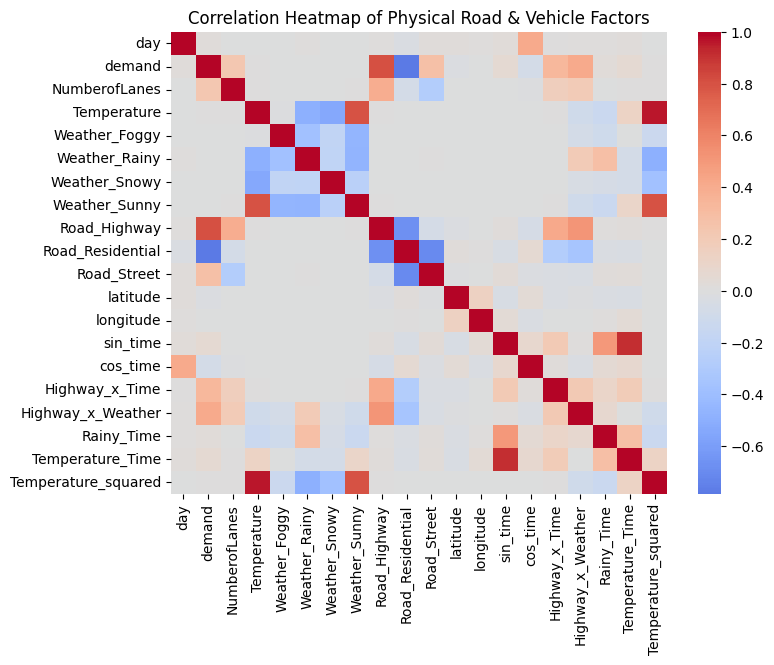

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = dataset.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Physical Road & Vehicle Factors")
plt.show()


In [103]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train, X_test, y_train, y_test = train_test_split(dataset.drop('demand', axis=1), dataset['demand'], test_size=0.2, random_state = 42)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

class SimpleLinearRegression(nn.Module):
  def __init__(self, input_size):
    super(SimpleLinearRegression, self).__init__()

    self.linear = nn.Linear(input_size, 1)

  def forward(self, x):
    return self.linear(x)

In [104]:
model = SimpleLinearRegression(input_size = X_train.shape[1])
model.to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

In [105]:
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1).to(device)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1).to(device)

train_data = TensorDataset(X_train_t, y_train_t)

dataloader = DataLoader(train_data, batch_size=32, shuffle=True)

for epoch in range(100):
  epoch_loss = 0.0
  for batch_X, batch_y in dataloader:
      optimizer.zero_grad()
      predictions = model(batch_X)
      loss = criterion(predictions, batch_y)

      loss.backward()

      optimizer.step()
      epoch_loss+=loss.item()
  avg_loss = epoch_loss / len(dataloader)
  if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.7f}")

Epoch 10, Avg Loss: 0.2525896
Epoch 20, Avg Loss: 0.2389070
Epoch 30, Avg Loss: 0.2369910
Epoch 40, Avg Loss: 0.2368854
Epoch 50, Avg Loss: 0.2364285
Epoch 60, Avg Loss: 0.2364463
Epoch 70, Avg Loss: 0.2362496
Epoch 80, Avg Loss: 0.2361117
Epoch 90, Avg Loss: 0.2359682
Epoch 100, Avg Loss: 0.2359235


In [106]:
model.eval()
preds = 0
with torch.no_grad():
    predictions = model(X_test_t)
    preds = predictions
    baseline_loss = torch.mean((y_test_t - y_test_t.mean())**2)
    model_loss = torch.mean((y_test_t - predictions)**2)
    print(f"Baseline Loss (predicting mean): {baseline_loss.item():.4f}")
    print(f"Model Loss: {model_loss.item():.4f}")

print(f"R-squared error = {1-(model_loss/baseline_loss)}")

Baseline Loss (predicting mean): 0.9879
Model Loss: 0.2286
R-squared error = 0.7686060667037964


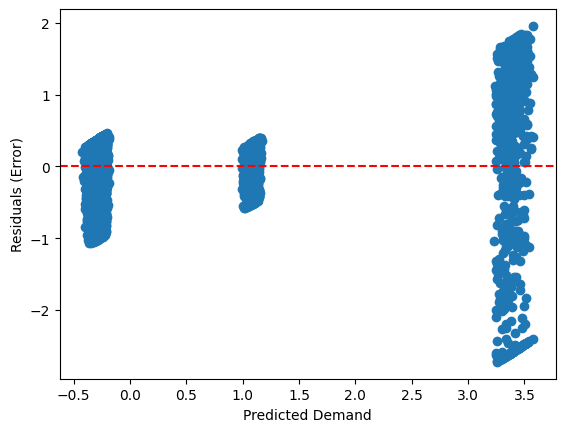

In [107]:
# 1. Move tensors to CPU and convert to NumPy arrays first
preds_np = preds.cpu().numpy()
# Ensure X_test_t is also moved to CPU if you want to use it
actuals_np = y_test_t.cpu().numpy()
# Check for patterns in the errors
residuals =preds_np - actuals_np
plt.scatter(preds_np, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Demand")
plt.ylabel("Residuals (Error)")
plt.show()